# Laboratorio 9  Datos Sintéticos

¿Por que una empresa podria no compartir sus datos reales?

por las leyes que defienden los datos personales de las personas

¿Que sesgos existen al utilizar información personal de clientes?


¿Crees que es posible entrenar un modemo de ML sin usar datos reales?

se puede entrenar haciendo uso de datasets sinteticos basados en algunos reales que se puedan encontrar, pero los resultados pueden no ser tan confiables


In [1]:
pip install  Faker

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# importar librerías

from faker import Faker
import pandas as pd
import random

In [3]:
# creamos una instancia de Faker
fake = Faker("es_MX")

In [7]:
# Generamos datos Sintéticos 100 registros

datos = []

for i in range(100): datos.append({
    "id_usuario":i + 1,
    "nombre":fake.name(),
    "correo":fake.email(),
    "edad":random.randint(18,65),
    "seguidores":random.randint(100,50000),
    "plataforma":random.choice(["TikTok","Instagram","YouTube"])
})

In [9]:
# creación del dataframe
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Margarita Loya Concepción,mitzy10@example.com,31,22388,TikTok
1,2,Rubén Madrigal Menchaca,silvia93@example.net,65,46318,Instagram
2,3,Rodolfo Jimínez,jimeneznoemi@example.net,53,19534,YouTube
3,4,Timoteo Mario Jáquez,zvillalpando@example.net,62,32440,YouTube
4,5,Dr. Juan Carlos Sevilla,judith98@example.com,24,2061,YouTube


In [10]:
#exploración del dataset
# ver si se hicieron los 100 registros
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  100 non-null    int64
 1   nombre      100 non-null    str  
 2   correo      100 non-null    str  
 3   edad        100 non-null    int64
 4   seguidores  100 non-null    int64
 5   plataforma  100 non-null    str  
dtypes: int64(3), str(3)
memory usage: 4.8 KB


In [11]:
# estadísticas descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.000000,100.000000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Margarita Loya Concepción,mitzy10@example.com,NaN,NaN,YouTube
freq,NaN,1,1,NaN,NaN,35
mean,50.500000,NaN,NaN,41.670000,25056.040000,NaN
std,29.011492,NaN,NaN,14.725128,13608.980495,NaN
min,1.000000,NaN,NaN,18.000000,328.000000,NaN
25%,25.750000,NaN,NaN,29.000000,14139.000000,NaN
50%,50.500000,NaN,NaN,40.000000,25548.000000,NaN
75%,75.250000,NaN,NaN,54.250000,36500.000000,NaN


In [12]:
# importar librerías para graficar
import seaborn as sns
import matplotlib.pyplot as plt

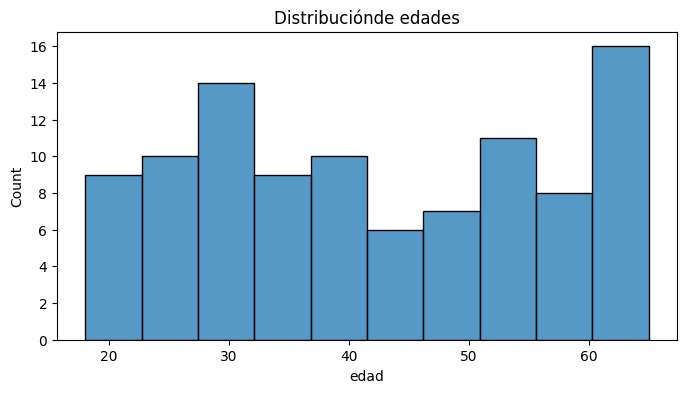

In [13]:
#distribución de edades
plt.figure(figsize=(8,4))

sns.histplot(
df["edad"],
bins=10
)

plt.title("Distribuciónde edades")
plt.show()

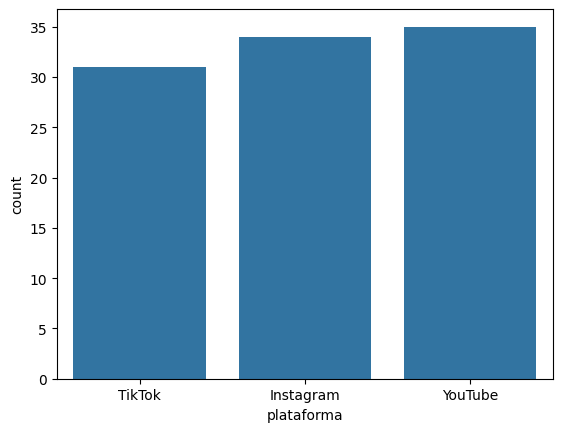

In [14]:
#usuarios por plataforma

sns.countplot(
x="plataforma",
data=df
)

plt.show()

In [15]:
#Generamos una copia para contaminarla

df_sucio =df.copy()

In [17]:
# colocamos valores nulos
# asognamos en 5 nombres, nada
for i in random.sample(range(len(df_sucio)),5): df_sucio.loc[i,"nombre"]  = None

In [18]:
#vemos que valores nos contaminó en el dataset para ensuciar en la col nombre
df_sucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_usuario  100 non-null    int64
 1   nombre      95 non-null     str  
 2   correo      100 non-null    str  
 3   edad        100 non-null    int64
 4   seguidores  100 non-null    int64
 5   plataforma  100 non-null    str  
dtypes: int64(3), str(3)
memory usage: 4.8 KB


In [20]:
#edades inválidas
# igual poner -10 en 5 edades
for i in random.sample(range(len(df_sucio)),5): df_sucio.loc[i,"edad"]  = -10

In [21]:
#vemos que valores nos contaminó en el dataset para ensuciar en la col edad
df_sucio.describe()["edad"]

count    100.000000
mean      39.060000
std       18.185809
min      -10.000000
25%       28.000000
50%       38.500000
75%       53.250000
max       65.000000
Name: edad, dtype: float64

In [22]:
#seguidores imposibles
for i in random.sample(range(len(df_sucio)),5): df_sucio.loc[i,"seguidores"]  = 5000000

In [33]:
#vemos que valores nos contaminó en el dataset para ensuciar en la col seguidores 
pd.set_option('display.float_format', '{:.2f}'.format)
df_sucio.describe()["seguidores"]

count       100.00
mean     274420.71
std     1089664.31
min         328.00
25%       16132.00
50%       26999.00
75%       37574.50
max     5000000.00
Name: seguidores, dtype: float64

In [25]:
#CORREOS inválidas
for i in random.sample(range(len(df_sucio)),5): df_sucio.loc[i,"correo"]  = "correo_invalido"

In [29]:
#vemos que valores nos contaminó en el dataset para ensuciar en la col seguidores 
df_sucio.describe(include=["str","object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Margarita Loya Concepción,correo_invalido,YouTube
freq,1,5,35


In [35]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [37]:
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.00,95,100,100.00,100.00,100
unique,NaN,95,96,NaN,NaN,3
top,NaN,Margarita Loya Concepción,correo_invalido,NaN,NaN,YouTube
freq,NaN,1,5,NaN,NaN,35
mean,50.50,NaN,NaN,39.06,274420.71,NaN
std,29.01,NaN,NaN,18.19,1089664.31,NaN
min,1.00,NaN,NaN,-10.00,328.00,NaN
25%,25.75,NaN,NaN,28.00,16132.00,NaN
50%,50.50,NaN,NaN,38.50,26999.00,NaN
75%,75.25,NaN,NaN,53.25,37574.50,NaN
